In [120]:
import numpy as np
import re
from scipy.linalg import solve_continuous_are

In [121]:
g = 9.81  # grawitacja [m/s^2]
c_ball = (5.0 / 7.0) * g  # ~7.0 m/s^2/rad
T_servo = 0.1

In [122]:
A = np.array([
    [0, 1, 0],           # dx/dt = v
    [0, 0, -c_ball],     # dv/dt = -c * theta
    [0, 0, -1/T_servo]   # dtheta/dt = -theta/T
])

B = np.array([
    [0],
    [0],
    [1/T_servo]
])

# ===========================================
# DOBIERANIE WAG - WAŻNE!
# ===========================================
# Twój zakres pozycji: 0-250mm = 0-0.25m
# Maksymalny błąd: ~125mm = 0.125m (od środka do krawędzi)
# Maksymalne wychylenie serwa: ±15° = ±0.26 rad
#
# Chcemy żeby przy max błędzie (0.125m) serwo wychyliło się ~10-15°
# u = K1 * x → 0.26 rad = K1 * 0.125m → K1 ≈ 2.0
#
# Żeby uzyskać K1 ≈ 2, potrzebujemy odpowiednich Q i R

Q_x = 100      # waga dla pozycji
Q_v = 10       # waga dla prędkości (tłumienie)
Q_theta = 1    # waga dla kąta belki

Q = np.diag([Q_x, Q_v, Q_theta])

# R - koszt sterowania (WIĘKSZE R = mniejsze K = łagodniejsze sterowanie)
R = np.array([[100]])  # Zwiększone R żeby K było mniejsze

# 4. ROZWIĄZANIE RÓWNANIA RICCATIEGO
P = solve_continuous_are(A, B, Q, R)
K = np.linalg.inv(R) @ B.T @ P

# WAŻNE: Bierzemy wartości bezwzględne bo w lqr.c mamy:
# u = K1*error - K2*velocity - K3*theta (gdzie K są DODATNIE)
# Model daje ujemne K1, K2 bo dv/dt = -c*theta ma minus
K1, K2, K3 = abs(K[0, 0]), abs(K[0, 1]), abs(K[0, 2])

print("=" * 50)
print("MODEL 3-STANOWY DLA SERWA POZYCYJNEGO")
print("=" * 50)
print(f"\nWagi Q = diag({Q_x}, {Q_v}, {Q_theta})")
print(f"Waga R = {R[0,0]}")
print(f"T_servo = {T_servo} s")
print(f"\nObliczona macierz wzmocnień K (wartości bezwzględne):")
print(f"  K1 = {K1:.4f}  (pozycja)")
print(f"  K2 = {K2:.4f}  (prędkość)")
print(f"  K3 = {K3:.4f}  (kąt belki)")

# Sprawdź co da max błąd (125mm = 0.125m)
max_error = 0.125  # m
u_max = K1 * max_error
print(f"\n--- WERYFIKACJA ---")
print(f"Przy max błędzie {max_error*1000:.0f}mm:")
print(f"  u = K1 * error = {K1:.2f} * {max_error} = {u_max:.3f} rad = {np.degrees(u_max):.1f}°")
print(f"  (Limit serwa: ±15°)")

if abs(np.degrees(u_max)) > 15:
    print(f"\n⚠️  UWAGA: Sterowanie przekracza limit serwa!")
    print(f"    Zwiększ R lub zmniejsz Q_x")
else:
    print(f"\n✅ OK: Sterowanie w zakresie serwa")

# =====================================================
# 5. AUTOMATYCZNA AKTUALIZACJA main.c
# =====================================================
main_c_path = r"STM\Core\Src\main.c"

try:
    with open(main_c_path, 'r', encoding='utf-8') as f:
        content = f.read()
    
    # Zamień wartości g_K1, g_K2, g_K3 (obsługuje też liczby ujemne)
    # Zawsze zapisujemy DODATNIE wartości!
    content = re.sub(
        r'volatile float g_K1 = -?[\d.]+f;',
        f'volatile float g_K1 = {K1:.2f}f;',
        content
    )
    content = re.sub(
        r'volatile float g_K2 = -?[\d.]+f;',
        f'volatile float g_K2 = {K2:.2f}f;',
        content
    )
    content = re.sub(
        r'volatile float g_K3 = -?[\d.]+f;',
        f'volatile float g_K3 = {K3:.2f}f;',
        content
    )
    
    with open(main_c_path, 'w', encoding='utf-8') as f:
        f.write(content)
    
    print(f"\n✅ Zaktualizowano {main_c_path}:")
    print(f"   g_K1 = {K1:.2f}f  (DODATNIE!)")
    print(f"   g_K2 = {K2:.2f}f  (DODATNIE!)")
    print(f"   g_K3 = {K3:.2f}f  (DODATNIE!)")
    print("\n⚠️  Przekompiluj projekt w STM32CubeIDE!")
    
except Exception as e:
    print(f"\n❌ Błąd aktualizacji main.c: {e}")

MODEL 3-STANOWY DLA SERWA POZYCYJNEGO

Wagi Q = diag(100, 10, 1)
Waga R = 100
T_servo = 0.1 s

Obliczona macierz wzmocnień K (wartości bezwzględne):
  K1 = 1.0000  (pozycja)
  K2 = 0.7100  (prędkość)
  K3 = 0.4160  (kąt belki)

--- WERYFIKACJA ---
Przy max błędzie 125mm:
  u = K1 * error = 1.00 * 0.125 = 0.125 rad = 7.2°
  (Limit serwa: ±15°)

✅ OK: Sterowanie w zakresie serwa

✅ Zaktualizowano STM\Core\Src\main.c:
   g_K1 = 1.00f  (DODATNIE!)
   g_K2 = 0.71f  (DODATNIE!)
   g_K3 = 0.42f  (DODATNIE!)

⚠️  Przekompiluj projekt w STM32CubeIDE!


K = [-44.72, -7.41, 2.52]


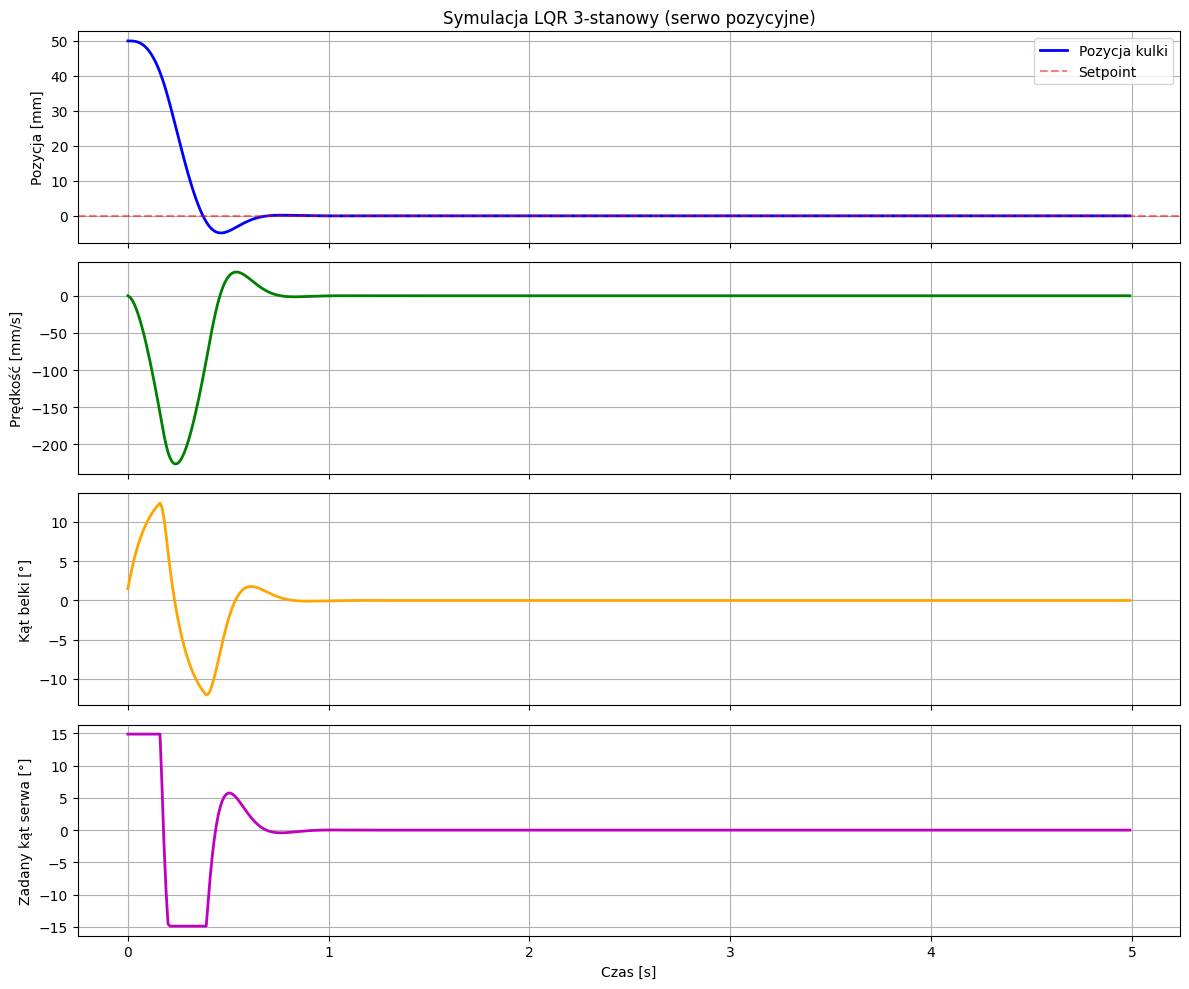


Czas stabilizacji (do <5mm): 0.34s


In [123]:
"""
SYMULACJA LQR - Model 3-stanowy z serwem pozycyjnym
"""
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_continuous_are

# Parametry (te same co wyżej)
g = 9.81
c_ball = (5.0 / 7.0) * g
T_servo = 0.1

# Model
A = np.array([
    [0, 1, 0],
    [0, 0, -c_ball],
    [0, 0, -1/T_servo]
])

B = np.array([
    [0],
    [0],
    [1/T_servo]
])

# Wagi - eksperymentuj z tymi wartościami!
Q = np.diag([2000, 10, 1])
R = np.array([[1]])

# Oblicz K
P = solve_continuous_are(A, B, Q, R)
K = np.linalg.inv(R) @ B.T @ P

print(f"K = [{K[0,0]:.2f}, {K[0,1]:.2f}, {K[0,2]:.2f}]")

# --- SYMULACJA ---
# Warunki początkowe: Kulka przesunięta o 50mm, belka pozioma
x_state = np.array([[0.05], [0], [0]])  # [x, v, theta]

dt = 0.01  # 100 Hz (jak na STM32)
time = np.arange(0, 5, dt)

history_x = []
history_v = []
history_theta = []
history_u = []

for t in time:
    # 1. Oblicz sterowanie LQR: u = -K * x
    u = -K @ x_state
    
    # Saturacja serwa (±15 stopni = ±0.26 rad)
    u = np.clip(u, -0.26, 0.26)
    
    # 2. Aktualizacja stanu (Euler)
    dx = A @ x_state + B @ u
    x_state = x_state + dx * dt
    
    history_x.append(x_state[0, 0] * 1000)  # mm
    history_v.append(x_state[1, 0] * 1000)  # mm/s
    history_theta.append(np.degrees(x_state[2, 0]))  # stopnie
    history_u.append(np.degrees(u[0, 0]))  # stopnie

# Wykresy
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes[0].plot(time, history_x, 'b-', linewidth=2)
axes[0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[0].set_ylabel("Pozycja [mm]")
axes[0].set_title("Symulacja LQR 3-stanowy (serwo pozycyjne)")
axes[0].grid(True)
axes[0].legend(["Pozycja kulki", "Setpoint"])

axes[1].plot(time, history_v, 'g-', linewidth=2)
axes[1].set_ylabel("Prędkość [mm/s]")
axes[1].grid(True)

axes[2].plot(time, history_theta, 'orange', linewidth=2)
axes[2].set_ylabel("Kąt belki [°]")
axes[2].grid(True)

axes[3].plot(time, history_u, 'm-', linewidth=2)
axes[3].set_ylabel("Zadany kąt serwa [°]")
axes[3].set_xlabel("Czas [s]")
axes[3].grid(True)

plt.tight_layout()
plt.show()

# Podsumowanie
print(f"\nCzas stabilizacji (do <5mm): ", end="")
for i, x in enumerate(history_x):
    if abs(x) < 5:
        print(f"{time[i]:.2f}s")
        break
else:
    print("Nie osiągnięto")